## Initialize

### Import

In [97]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import SET_USE_BIC_LLF
SET_USE_BIC_LLF(True)

import json
from xgboost import XGBClassifier
import shap

from sklearn.metrics import accuracy_score, f1_score, classification_report, make_scorer, roc_auc_score
from sklearn.model_selection import cross_validate
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import KFold

import matplotlib.pyplot as plt


### Define Functions

In [101]:
def glm_cv(X_train, y_train, k_splits=5):
    kf = KFold(n_splits=k_splits, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in kf.split(X_train):
        X_tr = sm.add_constant(X_train.iloc[train_idx].astype(float))
        X_val = sm.add_constant(X_train.iloc[val_idx].astype(float))
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]
        
        glm = sm.GLM(y_tr, X_tr, family=sm.families.Binomial()).fit()
        y_pred = glm.predict(X_val)
        
        scores.append({
            'ACC': accuracy_score(y_val, (y_pred >= 0.5).astype(int)),
            'F1': f1_score(y_val, (y_pred >= 0.5).astype(int), average='macro'),
            'AUC': roc_auc_score(y_val, y_pred)
        })
    
    for k in scores[0].keys():
        vals = [s[k] for s in scores]
        print(f"CV {k}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")

    pass

def stepwise_glm_backward(X, y, criterion="AIC", verbose=True):

    crit = criterion.upper()
    X_current = X.copy().astype(float)
    history = []
    iteration = 0

    while True:
        iteration += 1

        X_const = sm.add_constant(X_current)
        base_model = sm.GLM(y, X_const, family=sm.families.Binomial()).fit()

        base_score = base_model.aic if crit == "AIC" else base_model.bic
        base_rss = base_model.deviance

        if verbose:
            print(f"\nStep:  {crit}={base_score:.3f}")
            formula = "y ~ const + " + " + ".join(X_current.columns) if len(X_current.columns) > 0 else "y ~ 1"
            print(formula)
            print()
            
            # Header
            var_width = 75
            print("=" * 125)
            print(f"{'Variable':<{var_width}} {'Df':>8} {'Sum of Sq':>14} {'RSS':>14} {crit:>10}")
            print("-" * 125)

        best_score = base_score
        worst_feature = None
        best_model = base_model

        rows = []
        rows.append(("<none>", "", "", base_rss, base_score))

        for feature in X_current.columns:
            X_temp = X_current.drop(columns=[feature])
            X_temp_const = sm.add_constant(X_temp.astype(float))
            model_temp = sm.GLM(y, X_temp_const, family=sm.families.Binomial()).fit()

            rss = model_temp.deviance
            sumsq = rss - base_rss
            score = model_temp.aic if crit == "AIC" else model_temp.bic

            rows.append((f"- {feature}", 1, sumsq, rss, score))

            if score < best_score:
                best_score = score
                worst_feature = feature
                best_model = model_temp

        # Sort by AIC/BIC (ascending)
        rows_sorted = sorted(rows, key=lambda x: x[4])

        if verbose:
            var_width = 75
            for row in rows_sorted:
                var, df, sumsq, rss, sc = row
                if var == "<none>":
                    print(f"{var:<{var_width}} {'-':>8} {'-':>14} {rss:>14.3f} {sc:>10.3f}")
                else:
                    print(f"{var:<{var_width}} {df:>8} {sumsq:>14.3f} {rss:>14.3f} {sc:>10.3f}")
            print("=" * 125)

        if worst_feature is None:
            if verbose:
                print("\n>>> No improvement — stopping")
            break

        if verbose:
            print(f"\n>>> Removed: {worst_feature}  (New {crit}={best_score:.3f})")

        history.append({
            "Step": iteration,
            "Removed": worst_feature,
            crit: best_score
        })

        X_current = X_current.drop(columns=[worst_feature])

    return X_current, best_model, history




def stepwise_glm_forward(X, y, criterion="AIC", verbose=True):

    crit = criterion.upper()
    X_current = X.copy().astype(float)
    iteration = 0
    history = []

    # start with intercept-only model
    X_current = pd.DataFrame(index=X.index)

    base_const = sm.add_constant(X_current)
    base_model = sm.GLM(y, base_const, family=sm.families.Binomial()).fit()

    current_model = base_model
    current_rss = current_model.deviance
    current_aic = current_model.aic if crit == "AIC" else current_model.bic

    remaining = list(X.columns)
    iteration = 0

    while True:
        iteration += 1

        if verbose:
            print(f"\nStep:  {crit}={current_aic:.3f}")
            if len(X_current.columns) > 0:
                formula = "y ~ const + " + " + ".join(X_current.columns)
            else:
                formula = "y ~ 1 (intercept only)"
            print(formula)
            print()
            
            # Header
            var_width = 75
            print("=" * 125)
            print(f"{'Variable':<{var_width}} {'Df':>8} {'Sum of Sq':>14} {'RSS':>14} {crit:>10}")
            print("-" * 125)

        best_score = current_aic
        best_feature = None
        best_model_temp = current_model

        rows = []
        rows.append(("<none>", "", "", current_rss, current_aic))

        for feature in remaining:
            X_temp = pd.concat([X_current, X[[feature]]], axis=1)
            X_temp_const = sm.add_constant(X_temp.astype(float))
            model_temp = sm.GLM(y, X_temp_const, family=sm.families.Binomial()).fit()

            rss = model_temp.deviance
            sumsq = current_rss - rss  # positive = reduction in deviance (good)
            score = model_temp.aic if crit == "AIC" else model_temp.bic

            rows.append((f"+ {feature}", 1, sumsq, rss, score))

            if score < best_score:
                best_score = score
                best_feature = feature
                best_model_temp = model_temp

        # Sort by AIC/BIC (ascending) - best options first
        rows_sorted = sorted(rows, key=lambda x: x[4])

        if verbose:
            var_width = 75
            for row in rows_sorted:
                var, df, sumsq, rss, sc = row
                if var == "<none>":
                    print(f"{var:<{var_width}} {'-':>8} {'-':>14} {rss:>14.3f} {sc:>10.3f}")
                else:
                    print(f"{var:<{var_width}} {df:>8} {sumsq:>14.3f} {rss:>14.3f} {sc:>10.3f}")
            print("=" * 125)

        if best_feature is None:
            if verbose:
                print("\n>>> No improvement — stopping")
            break

        if verbose:
            print(f"\n>>> Added: {best_feature}  (New {crit}={best_score:.3f})")

        history.append({
            "Step": iteration,
            "Added": best_feature,
            crit: best_score
        })

        # update model
        X_current = pd.concat([X_current, X[[best_feature]]], axis=1)
        remaining.remove(best_feature)
        current_model = best_model_temp
        current_rss = current_model.deviance
        current_aic = best_score

        if len(remaining) == 0:
            if verbose:
                print("\n>>> No variables left — stopping")
            break

    return X_current, current_model, history

In [81]:
with open("PROCESSED/DATA/merged_and_dropped.cat_cols.json") as f:
    cat_cols = json.load(f)

X_train = pd.read_parquet("INPUTS/TRAIN/X_train.parquet")
X_test = pd.read_parquet("INPUTS/TEST/X_test.parquet")
y_train = pd.read_parquet("INPUTS/TRAIN/y_train.parquet")
y_test = pd.read_parquet("INPUTS/TEST/y_test.parquet")

# ordinal categorical columns
ordinal_cols = ['P_HUQ__HUQ010_General_health_condition', 'P_HUQ__HUQ051_times_receive_healthcare_over_past_year']

# drop ordinal from cat_cols
cat_cols = [c for c in cat_cols if c not in ordinal_cols]

X_train[cat_cols] = X_train[cat_cols].astype("category")
X_test[cat_cols] = X_test[cat_cols].astype("category")

num_cols = [c for c in X_train.columns if c not in cat_cols]

# one-hot encode categorical variables
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# ensure target is categorical
y_train_cat = y_train.iloc[:, 0].astype("category")
y_test_cat  = y_test.iloc[:, 0].astype("category")

In [105]:
# best parameters
with open("RESULTS/BASELINES/PARAMETERS/XGBClassifier_BEST_HYPER.json") as f:
    xgb_param = json.load(f)

# model with best parameters
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    **xgb_param
)

# cross-validation
scoring = {'accuracy': 'accuracy',
           'f1': make_scorer(f1_score, average='macro'),
           'auc': 'roc_auc'}
cv_results = cross_validate(xgb, X_train_encoded, y_train_cat, cv=5, scoring=scoring)

# fit
xgb.fit(X_train_encoded, y_train_cat)

# evaluate
y_pred_train = xgb.predict(X_train_encoded)
y_pred_test  = xgb.predict(X_test_encoded)

acc_train = accuracy_score(y_train_cat, y_pred_train)
acc_test  = accuracy_score(y_test_cat, y_pred_test)

f1_train = f1_score(y_train_cat, y_pred_train, average='macro')
f1_test  = f1_score(y_test_cat, y_pred_test, average='macro')

auc_train = roc_auc_score(y_train_cat, xgb.predict_proba(X_train_encoded)[:, 1])
auc_test  = roc_auc_score(y_test_cat, xgb.predict_proba(X_test_encoded)[:, 1])

print(f"CV accuracy    : {cv_results['test_accuracy'].mean():.3f}, F1: {cv_results['test_f1'].mean():.3f}, AUC: {cv_results['test_auc'].mean():.3f}")
print(f"Train accuracy : {acc_train:.3f}, F1: {f1_train:.3f}, AUC: {auc_train:.3f}")
print(f"Test  accuracy : {acc_test:.3f}, F1: {f1_test:.3f}, AUC: {auc_test:.3f}")

print(f"CV Accuracy    : {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
print(f"CV F1          : {cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}")
print(f"CV AUC         : {cv_results['test_auc'].mean():.3f} ± {cv_results['test_auc'].std():.3f}")


print("\nClassification report:\n")
print(classification_report(y_test_cat, y_pred_test))

CV accuracy    : 0.877, F1: 0.752, AUC: 0.903
Train accuracy : 0.941, F1: 0.888, AUC: 0.977
Test  accuracy : 0.900, F1: 0.788, AUC: 0.922
CV Accuracy    : 0.877 ± 0.002
CV F1          : 0.752 ± 0.004
CV AUC         : 0.903 ± 0.007

Classification report:

              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      1642
         1.0       0.74      0.55      0.63       306

    accuracy                           0.90      1948
   macro avg       0.83      0.76      0.79      1948
weighted avg       0.89      0.90      0.89      1948



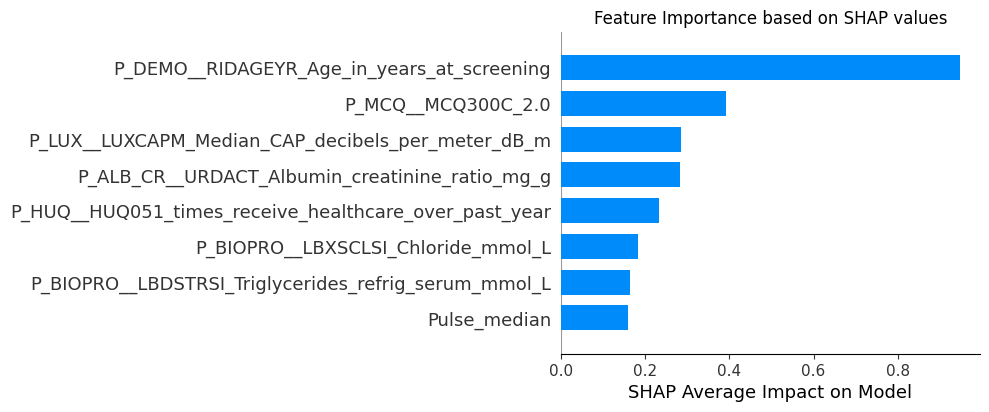

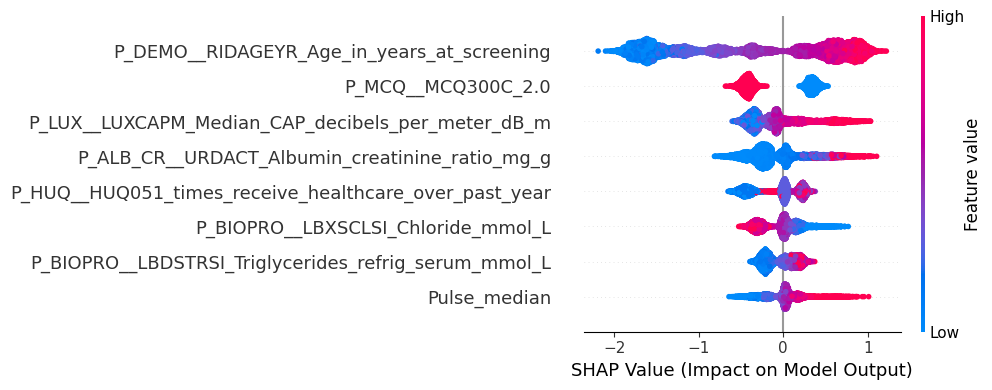

In [45]:
# 1. initialize explainer
explainer = shap.TreeExplainer(xgb)

# 2. compute SHAP values (main effects)
shap_values = explainer.shap_values(X_train_encoded)

feature_importance = np.abs(shap_values).mean(axis=0)
feature_names = X_train_encoded.columns

# global bar plot
shap.summary_plot(shap_values, X_train_encoded, plot_type="bar", max_display=8, plot_size=(10, 4), show=False)
plt.title("Feature Importance based on SHAP values")
plt.xlabel("SHAP Average Impact on Model")
plt.show()

# beeswarm plot
shap.summary_plot(shap_values, X_train_encoded, max_display=8, plot_size=(10, 4), show=False)
plt.xlabel("SHAP Value (Impact on Model Output)")
plt.show()

# Sort by importance
indices = np.argsort(feature_importance)[::-1][:15]

In [46]:
# # 3. (optional, can be slow) interaction values
# shap_interaction_values = explainer.shap_interaction_values(X_train_encoded)

# # 4. Compute mean absolute interaction values
# interaction_matrix = np.abs(shap_interaction_values).mean(axis=0)

# # 5. Turn into a ranked list of feature pairs
# top_idx = indices[:20] # top 20 features for interactions
# top_cols = X_train_encoded.columns[top_idx]
# pairs = []

# for i in range(len(top_cols)):
#     for j in range(i + 1, len(top_cols)):  # upper triangle only
#         pairs.append((top_cols[i], top_cols[j], interaction_matrix[top_idx[i], top_idx[j]]))

# interaction_df = pd.DataFrame(
#     pairs,
#     columns=["feature_1", "feature_2", "mean_abs_interaction"]
# ).sort_values("mean_abs_interaction", ascending=False)

# print(interaction_df)

## Untuned GLM

In [115]:
X_train_glm_untuned = sm.add_constant(X_train_encoded.astype(float))
X_test_glm_untuned = sm.add_constant(X_test_encoded.astype(float))

glm_untuned = sm.GLM(
    y_train,
    X_train_glm_untuned,
    family = sm.families.Binomial()
).fit()

# Predictions
y_pred_train_glm_untuned = glm_untuned.predict(X_train_glm_untuned)
y_pred_test_glm_untuned = glm_untuned.predict(X_test_glm_untuned)

y_pred_train_cat_untuned = (y_pred_train_glm_untuned >= 0.5).astype(int)
y_pred_test_cat_untuned = (y_pred_test_glm_untuned >= 0.5).astype(int)
acc_train_untuned = accuracy_score(y_train_cat, y_pred_train_cat_untuned)
acc_test_untuned = accuracy_score(y_test_cat, y_pred_test_cat_untuned)
f1_train_untuned = f1_score(y_train_cat, y_pred_train_cat_untuned, average='macro')
f1_test_untuned = f1_score(y_test_cat, y_pred_test_cat_untuned, average='macro')
auc_train_untuned = roc_auc_score(y_train_cat, y_pred_train_glm_untuned)
auc_test_untuned = roc_auc_score(y_test_cat, y_pred_test_glm_untuned)

print(f"Train accuracy: {acc_train_untuned:.3f},  F1: {f1_train_untuned:.3f}, AUC: {auc_train_untuned:.3f}")
print(f"Test  accuracy: {acc_test_untuned:.3f},  F1: {f1_test_untuned:.3f}, AUC: {auc_test_untuned:.3f}")
glm_cv(X_train_encoded, y_train)

print("\nClassification report:\n")
cls_report = classification_report(y_test_cat, y_pred_test_cat_untuned)
print(cls_report)

# Probabilty Outputs
test_df_untuned = pd.DataFrame(y_pred_test_glm_untuned, columns=["prob_1"])
test_df_untuned["y_true"] = np.asarray(y_test)

# Initialize DataFrame to store results
perf_df = pd.DataFrame(columns=[
    "model", "acc_train", "acc_test", 
    "f1_train", "f1_test", 
    "auc_train", "auc_test"
])

# Performance metrics
model_name = "GLM_UNTUNED"
perf_row = {
    "model": model_name,
    "acc_train": f"{acc_train_untuned:.3f}",
    "acc_test": f"{acc_test_untuned:.3f}",
    "f1_train": f"{f1_train_untuned:.3f}",
    "f1_test": f"{f1_test_untuned:.3f}",
    "auc_train": f"{auc_train_untuned:.3f}",
    "auc_test": f"{auc_test_untuned:.3f}",
}

perf_df = perf_df._append(perf_row, ignore_index=True)

print(glm_untuned.summary())

c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


Train accuracy: 0.863,  F1: 0.661, AUC: 0.626
Test  accuracy: 0.864,  F1: 0.638, AUC: 0.608


c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


CV ACC: 0.830 ± 0.028
CV F1: 0.714 ± 0.039
CV AUC: 0.768 ± 0.085

Classification report:

              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92      1642
         1.0       0.70      0.24      0.35       306

    accuracy                           0.86      1948
   macro avg       0.79      0.61      0.64      1948
weighted avg       0.85      0.86      0.83      1948

                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7405
Model Family:                Binomial   Df Model:                          383
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Thu, 27 Nov 2025   Deviance:                       98182.
Time:                        2

c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1056: RuntimeWarning: invalid value encountered in multiply
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +


## ML Tuned GLM

### XGB Gain Tuned GLM

In [113]:
# gain feature importance
booster = xgb.get_booster()
score = booster.get_score(importance_type='gain')

importance_df = pd.DataFrame({
    'feature': list(score.keys()),
    'importance': list(score.values())
}).sort_values('importance', ascending=False)

top_n = 100
top_features = importance_df['feature'].head(top_n).tolist()

# fit
X_train_glm_top = X_train_encoded[top_features]
X_test_glm_top = X_test_encoded[top_features]

X_train_glm_top = sm.add_constant(X_train_glm_top.astype(float))
X_test_glm_top = sm.add_constant(X_test_glm_top.astype(float))

glm_top = sm.GLM(
    y_train,
    X_train_glm_top,
    family=sm.families.Binomial()
).fit()


# Predictions
y_pred_train_glm_top = glm_top.predict(X_train_glm_top)
y_pred_test_glm_top = glm_top.predict(X_test_glm_top)

y_pred_train_cat_top = (y_pred_train_glm_top >= 0.5).astype(int)
y_pred_test_cat_top = (y_pred_test_glm_top >= 0.5).astype(int)
acc_train_top = accuracy_score(y_train_cat, y_pred_train_cat_top)
acc_test_top = accuracy_score(y_test_cat, y_pred_test_cat_top)
f1_train_top = f1_score(y_train_cat, y_pred_train_cat_top, average='macro')
f1_test_top = f1_score(y_test_cat, y_pred_test_cat_top, average='macro')
auc_train_top = roc_auc_score(y_train_cat, y_pred_train_glm_top)
auc_test_top = roc_auc_score(y_test_cat, y_pred_test_glm_top)
print(f"Train accuracy: {acc_train_top:.3f},  F1: {f1_train_top:.3f}, AUC: {auc_train_top:.3f}")
print(f"Test  accuracy: {acc_test_top:.3f},  F1: {f1_test_top:.3f}, AUC: {auc_test_top:.3f}")
glm_cv(X_train_glm_top, y_train)

print("\nClassification report:\n")
cls_report = classification_report(y_test_cat, y_pred_test_cat_top)
print(cls_report)

# Probabilty Outputs
test_df_top = pd.DataFrame(y_pred_test_glm_top, columns=["prob_1"])
test_df_top["y_true"] = np.asarray(y_test)

# Performance metrics
model_name = "GLM_TOP_FEATURES_GAIN"
perf_row = {
    "model": model_name,
    "acc_train": f"{acc_train_top:.3f}",
    "acc_test": f"{acc_test_top:.3f}",
    "f1_train": f"{f1_train_top:.3f}",
    "f1_test": f"{f1_test_top:.3f}",
    "auc_train": f"{auc_train_top:.3f}",
    "auc_test": f"{auc_test_top:.3f}",
}

perf_df = perf_df._append(perf_row, ignore_index=True)

print(glm_top.summary())

Train accuracy: 0.883,  F1: 0.770, AUC: 0.911
Test  accuracy: 0.891,  F1: 0.770, AUC: 0.913
CV ACC: 0.874 ± 0.004
CV F1: 0.753 ± 0.006
CV AUC: 0.899 ± 0.008

Classification report:

              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      1642
         1.0       0.70      0.53      0.60       306

    accuracy                           0.89      1948
   macro avg       0.81      0.74      0.77      1948
weighted avg       0.88      0.89      0.88      1948

                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7688
Model Family:                Binomial   Df Model:                          100
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2090.1
Date:            

### XGB SHAP Tuned GLM

In [102]:
# read trees
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train_encoded)
shap_vals = shap_values.values if hasattr(shap_values, "values") else shap_values
shap_feature_importance = np.abs(shap_vals).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': shap_feature_importance
}).sort_values('importance', ascending=False)

# read table
# path = './RESULTS/BASELINES/SHAP/XGBClassifier_SHAP.csv'
# shap_importance_df = pd.read_csv(path, index_col=0).reset_index()
# shap_importance_df.columns = ['feature', 'importance']
# shap_importance_df = shap_importance_df.sort_values('importance', ascending=False)

# top shap
top_n_shap = 100
top_features_shap = shap_importance_df['feature'].head(top_n_shap).tolist()

# fit
X_train_glm_shap = X_train_encoded[top_features_shap]
X_test_glm_shap = X_test_encoded[top_features_shap]

X_train_glm_shap_const = sm.add_constant(X_train_glm_shap.astype(float))
X_test_glm_shap_const = sm.add_constant(X_test_glm_shap.astype(float))

glm_shap = sm.GLM(
    y_train,
    X_train_glm_shap_const,
    family=sm.families.Binomial()
).fit()


# Predictions
y_pred_train_glm_shap = glm_shap.predict(X_train_glm_shap_const)
y_pred_test_glm_shap = glm_shap.predict(X_test_glm_shap_const)

y_pred_train_cat_shap = (y_pred_train_glm_shap >= 0.5).astype(int)
y_pred_test_cat_shap = (y_pred_test_glm_shap >= 0.5).astype(int)
acc_train_shap = accuracy_score(y_train_cat, y_pred_train_cat_shap)
acc_test_shap = accuracy_score(y_test_cat, y_pred_test_cat_shap)
f1_train_shap = f1_score(y_train_cat, y_pred_train_cat_shap, average='macro')
f1_test_shap = f1_score(y_test_cat, y_pred_test_cat_shap, average='macro')
auc_train_shap = roc_auc_score(y_train_cat, y_pred_train_glm_shap)
auc_test_shap = roc_auc_score(y_test_cat, y_pred_test_glm_shap)
print(f"Train accuracy: {acc_train_shap:.3f},  F1: {f1_train_shap:.3f}, AUC: {auc_train_shap:.3f}")
print(f"Test  accuracy: {acc_test_shap:.3f},  F1: {f1_test_shap:.3f}, AUC: {auc_test_shap:.3f}")
print(f"AIC = {glm_shap.aic:.3f}, BIC = {glm_shap.bic:.3f}")

vif_values = [variance_inflation_factor(X_train_glm_shap.astype(float).values, i) for i in range(X_train_glm_shap.astype(float).shape[1])]
max_vif = max(vif_values)
print(f"Max VIF: {max_vif:.3f}")

glm_cv(X_train_glm_shap, y_train)

print("\nClassification report:\n")
cls_report = classification_report(y_test_cat, y_pred_test_cat_shap)
print(cls_report)

# Probabilty Outputs
test_df_shap = pd.DataFrame(y_pred_test_glm_shap, columns=["prob_1"])
test_df_shap["y_true"] = np.asarray(y_test)

# Performance metrics
model_name = "GLM_TOP_FEATURES_SHAP"
perf_row = {
    "model": model_name,
    "acc_train": f"{acc_train_shap:.3f}",
    "acc_test": f"{acc_test_shap:.3f}",
    "f1_train": f"{f1_train_shap:.3f}",
    "f1_test": f"{f1_test_shap:.3f}",
    "auc_train": f"{auc_train_shap:.3f}",
    "auc_test": f"{auc_test_shap:.3f}",
}

perf_df = perf_df._append(perf_row, ignore_index=True)

print(glm_shap.summary())

Train accuracy: 0.883,  F1: 0.770, AUC: 0.915
Test  accuracy: 0.889,  F1: 0.767, AUC: 0.913
AIC = 4314.208, BIC = 5017.215
Max VIF: 641164.302
CV ACC: 0.875 ± 0.004
CV F1: 0.757 ± 0.006
CV AUC: 0.902 ± 0.008

Classification report:

              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      1642
         1.0       0.69      0.53      0.60       306

    accuracy                           0.89      1948
   macro avg       0.80      0.74      0.77      1948
weighted avg       0.88      0.89      0.88      1948

                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7688
Model Family:                Binomial   Df Model:                          100
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-L

## Statistical Tuning

#### Significance Backward Elimination

In [112]:
def backward_elimination_classification(X_train, y_train, p_threshold=0.05):
    """
    Backward elimination for classification (Binomial GLM).
    Removes highest p-value feature iteratively.
    """
    X_current = X_train.astype(float).copy()
    removed_features = []
    iteration = 0

    while True:
        iteration += 1

        X_const = sm.add_constant(X_current)

        model = sm.GLM(
            y_train,
            X_const,
            family=sm.families.Binomial()
        ).fit()

        pvalues = model.pvalues[1:]
        max_p = pvalues.max()
        worst_feat = pvalues.idxmax()

        y_pred_prob = model.predict(X_const)
        y_pred_class = (y_pred_prob >= 0.5).astype(int)

        acc = accuracy_score(y_train, y_pred_class)
        f1 = f1_score(y_train, y_pred_class, average='macro')
        auc = roc_auc_score(y_train, y_pred_prob)

        print("\n" + "="*80)
        print(f"Iteration {iteration}")
        print("="*80)
        print(f"Features remaining: {len(X_current.columns)}")
        print(f"Worst feature: {worst_feat}")
        print(f"Worst p-value: {max_p:.4f}")
        print(f"Train ACC: {acc:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

        if max_p < p_threshold:
            print(f"\n All features significant (p < {p_threshold})")
            break

        print(f"Removing: {worst_feat}")
        removed_features.append((worst_feat, max_p))
        X_current = X_current.drop(columns=[worst_feat])

    print("\n" + "="*80)
    print("BACKWARD ELIMINATION COMPLETE")
    print("="*80)
    print(f"Features removed: {len(removed_features)}")
    print(f"Features remaining: {len(X_current.columns)}")
    print("\nRemoved features:")
    for feat, pval in removed_features:
        print(f"  - {feat} (p = {pval:.4f})")

    return X_current, model, removed_features


# apply backward elimination
X_train_be, be_model, removed = backward_elimination_classification(
    X_train_glm_shap, y_train_cat, p_threshold=0.05
)

X_test_be = X_test_glm_shap[X_train_be.columns].astype(float)

X_train_be_const = sm.add_constant(X_train_be)
X_test_be_const = sm.add_constant(X_test_be)

y_train_prob = be_model.predict(X_train_be_const)
y_test_prob = be_model.predict(X_test_be_const)

y_train_pred = (y_train_prob >= 0.5).astype(int)
y_test_pred = (y_test_prob >= 0.5).astype(int)

acc_train_sig = accuracy_score(y_train, y_train_pred)
acc_test_sig = accuracy_score(y_test, y_test_pred)
f1_train_sig = f1_score(y_train, y_train_pred, average='macro')
f1_test_sig = f1_score(y_test, y_test_pred, average='macro')
auc_train_sig = roc_auc_score(y_train, y_train_prob)
auc_test_sig = roc_auc_score(y_test, y_test_prob)

print("\nFINAL RESULTS")
print(f"Train ACC: {acc_train_sig:.3f}, F1: {f1_train_sig:.3f}, AUC: {auc_train_sig:.3f}")
print(f"Test  ACC: {acc_test_sig:.3f}, F1: {f1_test_sig:.3f}, AUC: {auc_test_sig:.3f}")
glm_cv(X_train_be, y_train)

# Performance metrics
model_name = "GLM_SIGNIFICANT_FEATURES"
perf_row = {
    "model": model_name,
    "acc_train": f"{acc_train_sig:.3f}",
    "acc_test": f"{acc_test_sig:.3f}",
    "f1_train": f"{f1_train_sig:.3f}",
    "f1_test": f"{f1_test_sig:.3f}",
    "auc_train": f"{auc_train_sig:.3f}",
    "auc_test": f"{auc_test_sig:.3f}",
}

perf_df = perf_df._append(perf_row, ignore_index=True)

print("\n")
print(be_model.summary())


Iteration 1
Features remaining: 100
Worst feature: P_BIOPRO__LBDSCHSI_Cholesterol_refrigerated_serum_mmol_L
Worst p-value: 0.9791
Train ACC: 0.8825, F1: 0.7697, AUC: 0.9145
Removing: P_BIOPRO__LBDSCHSI_Cholesterol_refrigerated_serum_mmol_L

Iteration 2
Features remaining: 99
Worst feature: P_ALB_CR__URXUMS_Albumin_urine_mg_L
Worst p-value: 0.9683
Train ACC: 0.8825, F1: 0.7697, AUC: 0.9145
Removing: P_ALB_CR__URXUMS_Albumin_urine_mg_L

Iteration 3
Features remaining: 98
Worst feature: P_ALB_CR__URXCRS_Creatinine_urine_umol_L
Worst p-value: 0.9351
Train ACC: 0.8824, F1: 0.7694, AUC: 0.9145
Removing: P_ALB_CR__URXCRS_Creatinine_urine_umol_L

Iteration 4
Features remaining: 97
Worst feature: P_MCQ__MCQ366A_2.0
Worst p-value: 0.9012
Train ACC: 0.8824, F1: 0.7692, AUC: 0.9145
Removing: P_MCQ__MCQ366A_2.0

Iteration 5
Features remaining: 96
Worst feature: P_BIOPRO__LBXSCK_Creatine_Phosphokinase_CPK_IU_L
Worst p-value: 0.8414
Train ACC: 0.8825, F1: 0.7694, AUC: 0.9145
Removing: P_BIOPRO__LBXS

#### Stepwise Selection

##### AIC Backward

In [52]:
X_step_aic_backward, model_aic_backward, history_aic_backward = stepwise_glm_backward(X_train_be, y_train, criterion="AIC")


Step:  AIC=4279.522
y ~ const + P_DEMO__RIDAGEYR_Age_in_years_at_screening + P_MCQ__MCQ300C_2.0 + P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m + P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g + P_HUQ__HUQ051_times_receive_healthcare_over_past_year + P_BIOPRO__LBXSCLSI_Chloride_mmol_L + P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L + Pulse_median + P_PBCD__LBDBPBSI_Blood_lead_umol_L + P_MCQ__MCQ366D_2.0 + P_BPQ__BPQ020_Ever_told_you_had_high_blood_pressure_2.0 + P_HUQ__HUQ010_General_health_condition + P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0 + P_BMX__BMXWAIST_Waist_Circumference_cm + P_TCHOL__LBDTCSI_Total_Cholesterol_mmol_L + P_BIOPRO__LBXSLDSI_Lactate_Dehydrogenase_LDH_IU_L + P_WHQ__WHQ150_Age_when_heaviest_weight + P_TST__LBXSHBG_SHBG_nmol_L + P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0 + P_LUX__LUXSMED_Median_stiffness_E_kilopascals_kPa + P_WHQ__WHD140_Self_reported_greatest_weight_pounds + P_PAQ__PAQ620_Moderate_work_activity_2.0 + P_CBC__LBXMPS

In [111]:
X_train_aic_bwd_const = sm.add_constant(X_step_aic_backward.astype(float))
X_test_aic_bwd = X_test_be[X_step_aic_backward.columns].astype(float)
X_test_aic_bwd_const = sm.add_constant(X_test_aic_bwd)

y_train_prob_aic_bwd = model_aic_backward.predict(X_train_aic_bwd_const)
y_test_prob_aic_bwd  = model_aic_backward.predict(X_test_aic_bwd_const)

y_train_pred_aic_bwd = (y_train_prob_aic_bwd >= 0.5).astype(int)
y_test_pred_aic_bwd  = (y_test_prob_aic_bwd >= 0.5).astype(int)

acc_train_aic_bwd = accuracy_score(y_train, y_train_pred_aic_bwd)
acc_test_aic_bwd  = accuracy_score(y_test, y_test_pred_aic_bwd)
f1_train_aic_bwd  = f1_score(y_train, y_train_pred_aic_bwd, average='macro')
f1_test_aic_bwd   = f1_score(y_test, y_test_pred_aic_bwd, average='macro')
auc_train_aic_bwd = roc_auc_score(y_train, y_train_prob_aic_bwd)
auc_test_aic_bwd  = roc_auc_score(y_test, y_test_prob_aic_bwd)

print(f"Train ACC: {acc_train_aic_bwd:.3f}, F1: {f1_train_aic_bwd:.3f}, AUC: {auc_train_aic_bwd:.3f}")
print(f"Test  ACC: {acc_test_aic_bwd:.3f}, F1: {f1_test_aic_bwd:.3f}, AUC: {auc_test_aic_bwd:.3f}\n")
glm_cv(X_step_aic_backward, y_train)

# Performance metrics
model_name = "GLM_AIC_BACKWARD"
perf_row = {
    "model": model_name,
    "acc_train": f"{acc_train_aic_bwd:.3f}",
    "acc_test": f"{acc_test_aic_bwd:.3f}",
    "f1_train": f"{f1_train_aic_bwd:.3f}",
    "f1_test": f"{f1_test_aic_bwd:.3f}",
    "auc_train": f"{auc_train_aic_bwd:.3f}",
    "auc_test": f"{auc_test_aic_bwd:.3f}",
}

perf_df = perf_df._append(perf_row, ignore_index=True)

print(f"AIC = {model_aic_backward.aic:.3f}, BIC = {model_aic_backward.bic:.3f}")
print(model_aic_backward.summary())


Train ACC: 0.880, F1: 0.763, AUC: 0.912
Test  ACC: 0.894, F1: 0.778, AUC: 0.912

CV ACC: 0.874 ± 0.004
CV F1: 0.753 ± 0.007
CV AUC: 0.905 ± 0.008
AIC = 4279.522, BIC = 4676.269
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7732
Model Family:                Binomial   Df Model:                           56
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2082.8
Date:                Thu, 27 Nov 2025   Deviance:                       4165.5
Time:                        20:34:05   Pearson chi2:                 7.14e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3190
Covariance Type:            nonrobust                                         
                                 

##### BIC Backward

In [54]:
X_step_bic_backward, model_bic_backward, history_bic_backward = stepwise_glm_backward(X_train_be, y_train, criterion="BIC")


Step:  BIC=4676.269
y ~ const + P_DEMO__RIDAGEYR_Age_in_years_at_screening + P_MCQ__MCQ300C_2.0 + P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m + P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g + P_HUQ__HUQ051_times_receive_healthcare_over_past_year + P_BIOPRO__LBXSCLSI_Chloride_mmol_L + P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L + Pulse_median + P_PBCD__LBDBPBSI_Blood_lead_umol_L + P_MCQ__MCQ366D_2.0 + P_BPQ__BPQ020_Ever_told_you_had_high_blood_pressure_2.0 + P_HUQ__HUQ010_General_health_condition + P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0 + P_BMX__BMXWAIST_Waist_Circumference_cm + P_TCHOL__LBDTCSI_Total_Cholesterol_mmol_L + P_BIOPRO__LBXSLDSI_Lactate_Dehydrogenase_LDH_IU_L + P_WHQ__WHQ150_Age_when_heaviest_weight + P_TST__LBXSHBG_SHBG_nmol_L + P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0 + P_LUX__LUXSMED_Median_stiffness_E_kilopascals_kPa + P_WHQ__WHD140_Self_reported_greatest_weight_pounds + P_PAQ__PAQ620_Moderate_work_activity_2.0 + P_CBC__LBXMPS

In [110]:
X_train_bic_bwd_const = sm.add_constant(X_step_bic_backward.astype(float))
X_test_bic_bwd = X_test_be[X_step_bic_backward.columns].astype(float)
X_test_bic_bwd_const  = sm.add_constant(X_test_bic_bwd)

y_train_prob_bic_bwd = model_bic_backward.predict(X_train_bic_bwd_const)
y_test_prob_bic_bwd  = model_bic_backward.predict(X_test_bic_bwd_const)

y_train_pred_bic_bwd = (y_train_prob_bic_bwd >= 0.5).astype(int)
y_test_pred_bic_bwd  = (y_test_prob_bic_bwd >= 0.5).astype(int)

acc_train_bic_bwd = accuracy_score(y_train, y_train_pred_bic_bwd)
acc_test_bic_bwd  = accuracy_score(y_test, y_test_pred_bic_bwd)
f1_train_bic_bwd  = f1_score(y_train, y_train_pred_bic_bwd, average='macro')
f1_test_bic_bwd   = f1_score(y_test, y_test_pred_bic_bwd, average='macro')
auc_train_bic_bwd = roc_auc_score(y_train, y_train_prob_bic_bwd)
auc_test_bic_bwd  = roc_auc_score(y_test, y_test_prob_bic_bwd)

print(f"Train ACC: {acc_train_bic_bwd:.3f}, F1: {f1_train_bic_bwd:.3f}, AUC: {auc_train_bic_bwd:.3f}")
print(f"Test  ACC: {acc_test_bic_bwd:.3f}, F1: {f1_test_bic_bwd:.3f}, AUC: {auc_test_bic_bwd:.3f}\n")
glm_cv(X_step_bic_backward, y_train)

# Performance metrics
model_name = "GLM_BIC_BACKWARD"
perf_row = {
    "model": model_name,
    "acc_train": f"{acc_train_bic_bwd:.3f}",
    "acc_test": f"{acc_test_bic_bwd:.3f}",
    "f1_train": f"{f1_train_bic_bwd:.3f}",
    "f1_test": f"{f1_test_bic_bwd:.3f}",
    "auc_train": f"{auc_train_bic_bwd:.3f}",
    "auc_test": f"{auc_test_bic_bwd:.3f}",
}

perf_df = perf_df._append(perf_row, ignore_index=True)

print(f"AIC = {model_bic_backward.aic:.3f}, BIC = {model_bic_backward.bic:.3f}")
print(model_bic_backward.summary())

Train ACC: 0.877, F1: 0.755, AUC: 0.907
Test  ACC: 0.899, F1: 0.789, AUC: 0.913

CV ACC: 0.876 ± 0.006
CV F1: 0.756 ± 0.011
CV AUC: 0.902 ± 0.007
AIC = 4345.355, BIC = 4616.813
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7750
Model Family:                Binomial   Df Model:                           38
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2133.7
Date:                Thu, 27 Nov 2025   Deviance:                       4267.4
Time:                        20:32:38   Pearson chi2:                 6.86e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3101
Covariance Type:            nonrobust                                         
                                 

##### AIC Forward

In [56]:
X_step_aic_forward, model_aic_forward, history_aic_forward = stepwise_glm_forward(X_train_be, y_train, criterion="AIC")


Step:  AIC=7160.176
y ~ 1 (intercept only)

Variable                                                                          Df      Sum of Sq            RSS        AIC
-----------------------------------------------------------------------------------------------------------------------------
+ P_DEMO__RIDAGEYR_Age_in_years_at_screening                                       1        990.705       6167.471   6171.471
+ P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m                                1        763.581       6394.596   6398.596
+ P_BPQ__BPQ020_Ever_told_you_had_high_blood_pressure_2.0                          1        756.069       6402.108   6406.108
+ P_BMX__BMXWAIST_Waist_Circumference_cm                                           1        666.701       6491.475   6495.475
+ P_WHQ__WHQ150_Age_when_heaviest_weight                                           1        608.481       6549.696   6553.696
+ P_MCQ__MCQ366D_2.0                                                     

In [109]:
X_train_aic_fwd_const = sm.add_constant(X_step_aic_forward.astype(float))
X_test_aic_fwd = X_test_be[X_step_aic_forward.columns].astype(float)
X_test_aic_fwd_const  = sm.add_constant(X_test_aic_fwd)

y_train_prob_aic_fwd = model_aic_forward.predict(X_train_aic_fwd_const)
y_test_prob_aic_fwd  = model_aic_forward.predict(X_test_aic_fwd_const)
y_train_pred_aic_fwd = (y_train_prob_aic_fwd >= 0.5).astype(int)
y_test_pred_aic_fwd  = (y_test_prob_aic_fwd >= 0.5).astype(int)

acc_train_aic_fwd = accuracy_score(y_train, y_train_pred_aic_fwd)
acc_test_aic_fwd  = accuracy_score(y_test, y_test_pred_aic_fwd)
f1_train_aic_fwd  = f1_score(y_train, y_train_pred_aic_fwd, average='macro')
f1_test_aic_fwd   = f1_score(y_test, y_test_pred_aic_fwd, average='macro')
auc_train_aic_fwd = roc_auc_score(y_train, y_train_prob_aic_fwd)
auc_test_aic_fwd  = roc_auc_score(y_test, y_test_prob_aic_fwd)

print(f"Train ACC: {acc_train_aic_fwd:.3f}, F1: {f1_train_aic_fwd:.3f}, AUC: {auc_train_aic_fwd:.3f}")
print(f"Test  ACC: {acc_test_aic_fwd:.3f}, F1: {f1_test_aic_fwd:.3f}, AUC: {auc_test_aic_fwd:.3f}\n")
glm_cv(X_step_aic_forward, y_train)

# Performance metrics
model_name = "GLM_AIC_FORWARD"
perf_row = {
    "model": model_name,
    "acc_train": f"{acc_train_aic_fwd:.3f}",
    "acc_test": f"{acc_test_aic_fwd:.3f}",
    "f1_train": f"{f1_train_aic_fwd:.3f}",
    "f1_test": f"{f1_test_aic_fwd:.3f}",
    "auc_train": f"{auc_train_aic_fwd:.3f}",
    "auc_test": f"{auc_test_aic_fwd:.3f}",
}

perf_df = perf_df._append(perf_row, ignore_index=True)

print(f"AIC = {model_aic_forward.aic:.3f}, BIC = {model_aic_forward.bic:.3f}")
print(model_aic_forward.summary())

Train ACC: 0.880, F1: 0.763, AUC: 0.912
Test  ACC: 0.894, F1: 0.778, AUC: 0.912

CV ACC: 0.874 ± 0.004
CV F1: 0.753 ± 0.007
CV AUC: 0.905 ± 0.008
AIC = 4279.522, BIC = 4676.269
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7732
Model Family:                Binomial   Df Model:                           56
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2082.8
Date:                Thu, 27 Nov 2025   Deviance:                       4165.5
Time:                        20:30:02   Pearson chi2:                 7.14e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3190
Covariance Type:            nonrobust                                         
                                 

##### BIC Forward

In [58]:
X_step_bic_forward, model_bic_forward, history_bic_forward = stepwise_glm_forward(X_train_be, y_train, criterion="BIC")


Step:  BIC=7167.137
y ~ 1 (intercept only)

Variable                                                                          Df      Sum of Sq            RSS        BIC
-----------------------------------------------------------------------------------------------------------------------------
+ P_DEMO__RIDAGEYR_Age_in_years_at_screening                                       1        990.705       6167.471   6185.392
+ P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m                                1        763.581       6394.596   6412.516
+ P_BPQ__BPQ020_Ever_told_you_had_high_blood_pressure_2.0                          1        756.069       6402.108   6420.028
+ P_BMX__BMXWAIST_Waist_Circumference_cm                                           1        666.701       6491.475   6509.396
+ P_WHQ__WHQ150_Age_when_heaviest_weight                                           1        608.481       6549.696   6567.617
+ P_MCQ__MCQ366D_2.0                                                     

In [108]:
X_train_bic_fwd_const = sm.add_constant(X_step_bic_forward.astype(float))
X_test_bic_fwd = X_test_be[X_step_bic_forward.columns].astype(float)
X_test_bic_fwd_const  = sm.add_constant(X_test_bic_fwd)

y_train_prob_bic_fwd = model_bic_forward.predict(X_train_bic_fwd_const)
y_test_prob_bic_fwd  = model_bic_forward.predict(X_test_bic_fwd_const)
y_train_pred_bic_fwd = (y_train_prob_bic_fwd >= 0.5).astype(int)
y_test_pred_bic_fwd  = (y_test_prob_bic_fwd >= 0.5).astype(int)

acc_train_bic_fwd = accuracy_score(y_train, y_train_pred_bic_fwd)
acc_test_bic_fwd  = accuracy_score(y_test, y_test_pred_bic_fwd)
f1_train_bic_fwd  = f1_score(y_train, y_train_pred_bic_fwd, average='macro')
f1_test_bic_fwd   = f1_score(y_test, y_test_pred_bic_fwd, average='macro')
auc_train_bic_fwd = roc_auc_score(y_train, y_train_prob_bic_fwd)
auc_test_bic_fwd  = roc_auc_score(y_test, y_test_prob_bic_fwd)

print(f"Train ACC: {acc_train_bic_fwd:.3f}, F1: {f1_train_bic_fwd:.3f}, AUC: {auc_train_bic_fwd:.3f}")
print(f"Test  ACC: {acc_test_bic_fwd:.3f}, F1: {f1_test_bic_fwd:.3f}, AUC: {auc_test_bic_fwd:.3f}\n")
glm_cv(X_step_bic_forward, y_train)

# Performance metrics
model_name = "GLM_BIC_FORWARD"
perf_row = {
    "model": model_name,
    "acc_train": f"{acc_train_bic_fwd:.3f}",
    "acc_test": f"{acc_test_bic_fwd:.3f}",
    "f1_train": f"{f1_train_bic_fwd:.3f}",
    "f1_test": f"{f1_test_bic_fwd:.3f}",
    "auc_train": f"{auc_train_bic_fwd:.3f}",
    "auc_test": f"{auc_test_bic_fwd:.3f}",
}

perf_df = perf_df._append(perf_row, ignore_index=True)

print(f"AIC = {model_bic_forward.aic:.3f}, BIC = {model_bic_forward.bic:.3f}")
print(model_bic_forward.summary())

Train ACC: 0.875, F1: 0.752, AUC: 0.904
Test  ACC: 0.897, F1: 0.782, AUC: 0.904

CV ACC: 0.874 ± 0.003
CV F1: 0.749 ± 0.006
CV AUC: 0.899 ± 0.005
AIC = 4400.375, BIC = 4623.110
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7757
Model Family:                Binomial   Df Model:                           31
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2168.2
Date:                Thu, 27 Nov 2025   Deviance:                       4336.4
Time:                        20:29:26   Pearson chi2:                 7.37e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3039
Covariance Type:            nonrobust                                         
                                 

#### VIF Drops

##### VIF Auto-tune

In [60]:
# apply VIF with thresholds
numeric_cols = X_step_bic_forward.select_dtypes(include=['number']).columns.tolist()
X_vif = X_step_bic_forward[numeric_cols].dropna()

vif_thresholds = [100, 60, 40, 30, 20, 10, 5]
threshold_results = {}
current_threshold_idx = 0

# Initialize
vif_summary = pd.DataFrame({'feature': X_vif.columns})

iteration = 0
print(f"Starting with {len(X_vif.columns)} features\n")

while current_threshold_idx < len(vif_thresholds):
    iteration += 1
    
    # Calculate VIF
    vif_values = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    max_vif = max(vif_values)
    
    vif = pd.DataFrame({
        'feature': X_vif.columns,
        f'VIF_iter{iteration}': vif_values
    })
    
    vif_summary = vif_summary.merge(vif, on='feature', how='left')
    
    current_threshold = vif_thresholds[current_threshold_idx]
    
    # Check if we've dropped below current threshold
    if max_vif < current_threshold:
        print(f"\n{'='*60}")
        print(f"VIF < {current_threshold} REACHED")
        print(f"{'='*60}")
        
        # Save results for this threshold
        final_features = X_vif.columns.tolist()
        threshold_results[current_threshold] = {
            'features': final_features,
            'n_features': len(final_features)
        }
        
        # Save files - ALL AS CSV IN INPUT/MISC
        # vif_summary.to_csv(f"LOG/VIF_log_threshold_{current_threshold}.csv", index=False)
        # pd.DataFrame({'feature': final_features}).to_csv(
        #     f"INPUT/MISC/selected_features_vif_{current_threshold}.csv", index=False
        # )
        
        print(f"Features remaining: {len(final_features)}")
        print(f"Features removed: {len(numeric_cols) - len(final_features)}")
        
        # Move to next threshold
        current_threshold_idx += 1
        
        # If we've reached the last threshold, break
        if current_threshold_idx >= len(vif_thresholds):
            break
        
        continue
    
    # Find max VIF and drop
    max_idx = vif_values.index(max_vif)
    drop_col = X_vif.columns[max_idx]
    
    print(f"[{iteration}] Drop {drop_col}: VIF={max_vif:.1f}")
    X_vif = X_vif.drop(columns=drop_col)

# Summary comparison
print("\n" + "="*60)
print("SUMMARY: Feature Count by VIF Threshold")
print("="*60)
print(f"{'Threshold':<12} {'Features':<12} {'Removed':<12} {'% Remaining':<12}")
print("-"*60)

for threshold in vif_thresholds:
    if threshold in threshold_results:
        n_features = threshold_results[threshold]['n_features']
        n_removed = len(numeric_cols) - n_features
        pct_remaining = (n_features / len(numeric_cols)) * 100
        print(f"VIF < {threshold:<6} {n_features:<12} {n_removed:<12} {pct_remaining:.1f}%")

# Save comparison summary
comparison_df = pd.DataFrame({
    'VIF_Threshold': list(threshold_results.keys()),
    'Features_Remaining': [threshold_results[t]['n_features'] for t in threshold_results.keys()],
    'Features_Removed': [len(numeric_cols) - threshold_results[t]['n_features'] for t in threshold_results.keys()],
    'Percent_Remaining': [(threshold_results[t]['n_features'] / len(numeric_cols)) * 100 for t in threshold_results.keys()]
})
# comparison_df.to_csv("LOG/VIF_threshold_comparison.csv", index=False)

# print(f"\nFiles saved:")
# print(f"  - LOG/VIF_log_threshold_[5|10|20|30|40].csv")
# print(f"  - INPUT/MISC/selected_features_vif_[5|10|20|30|40].csv")
# print(f"  - LOG/VIF_threshold_comparison.csv")

Starting with 31 features

[1] Drop P_BIOPRO__LBXSCLSI_Chloride_mmol_L: VIF=405.8
[2] Drop P_BMX__BMXWAIST_Waist_Circumference_cm: VIF=272.8
[3] Drop P_BMX__BMXHIP_Hip_Circumference_cm: VIF=136.9
[4] Drop P_BMX__BMXLEG_Upper_Leg_Length_cm: VIF=122.1
[5] Drop BP_sys_median: VIF=116.7

VIF < 100 REACHED
Features remaining: 26
Features removed: 5
[7] Drop P_BIOPRO__LBXSC3SI_Bicarbonate_mmol_L: VIF=83.0

VIF < 60 REACHED
Features remaining: 25
Features removed: 6
[9] Drop P_CBC__LBXMPSI_Mean_platelet_volume_fL: VIF=58.5
[10] Drop BP_dia_median: VIF=51.0

VIF < 40 REACHED
Features remaining: 23
Features removed: 8
[12] Drop Pulse_median: VIF=37.8

VIF < 30 REACHED
Features remaining: 22
Features removed: 9
[14] Drop P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m: VIF=27.4
[15] Drop P_TCHOL__LBDTCSI_Total_Cholesterol_mmol_L: VIF=26.4
[16] Drop P_BIOPRO__LBXSLDSI_Lactate_Dehydrogenase_LDH_IU_L: VIF=21.9

VIF < 20 REACHED
Features remaining: 19
Features removed: 12
[18] Drop P_HDL__LBDHDDSI

In [117]:
# choose VIF cutoff
n_VIF_thresh = 20
print(f"\nEvaluating GLM with VIF < {n_VIF_thresh} features\n")

# get selected feature list
vif_features = threshold_results[n_VIF_thresh]['features']

# subset TRAIN and TEST using those features
X_train_vif = X_train_be[vif_features]
X_test_vif  = X_test_be[vif_features]

# add constant
X_train_vif_const = sm.add_constant(X_train_vif.astype(float))
X_test_vif_const  = sm.add_constant(X_test_vif.astype(float))

# refit GLM
glm_vif = sm.GLM(
    y_train,
    X_train_vif_const,
    family=sm.families.Binomial()
).fit()

# predictions
y_train_prob_vif = glm_vif.predict(X_train_vif_const)
y_test_prob_vif  = glm_vif.predict(X_test_vif_const)

y_train_pred_vif = (y_train_prob_vif >= 0.5).astype(int)
y_test_pred_vif  = (y_test_prob_vif >= 0.5).astype(int)

# metrics
acc_train_vif = accuracy_score(y_train_cat, y_train_pred_vif)
acc_test_vif  = accuracy_score(y_test_cat, y_test_pred_vif)
f1_train_vif  = f1_score(y_train_cat, y_train_pred_vif, average='macro')
f1_test_vif   = f1_score(y_test_cat, y_test_pred_vif, average='macro')
auc_train_vif = roc_auc_score(y_train_cat, y_train_prob_vif)
auc_test_vif  = roc_auc_score(y_test_cat, y_test_prob_vif)

print(f"Train ACC: {acc_train_vif:.3f}, F1: {f1_train_vif:.3f}, AUC: {auc_train_vif:.3f}")
print(f"Test  ACC: {acc_test_vif:.3f}, F1: {f1_test_vif:.3f}, AUC: {auc_test_vif:.3f}\n")
glm_cv(X_train_vif, y_train)

print(glm_vif.summary())


Evaluating GLM with VIF < 20 features

Train ACC: 0.858, F1: 0.703, AUC: 0.877
Test  ACC: 0.878, F1: 0.724, AUC: 0.884

CV ACC: 0.855 ± 0.007
CV F1: 0.697 ± 0.009
CV AUC: 0.875 ± 0.005
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7769
Model Family:                Binomial   Df Model:                           19
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2412.6
Date:                Thu, 27 Nov 2025   Deviance:                       4825.2
Time:                        20:49:58   Pearson chi2:                 9.19e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2588
Covariance Type:            nonrobust                                         
                        

##### VIF-LRT Manual Tune

In [62]:
def lr_importance(X, y, features):
    full_model = sm.GLM(y, sm.add_constant(X), family=sm.families.Binomial()).fit()
    
    importance = {}
    for feat in features:
        X_reduced = X.drop(columns=[feat])
        reduced = sm.GLM(y, sm.add_constant(X_reduced), family=sm.families.Binomial()).fit()
        lr_stat = 2 * (full_model.llf - reduced.llf)  # chi-square statistic
        importance[feat] = lr_stat
    
    return pd.Series(importance).sort_values(ascending=False)

lr_importances = lr_importance(X_step_bic_forward, y_train, X_step_bic_forward.columns)
print("\nLog-Likelihood Ratio Importances:")
print(lr_importances.to_string())


Log-Likelihood Ratio Importances:
P_DEMO__RIDAGEYR_Age_in_years_at_screening                330.531880
P_MCQ__MCQ300C_2.0                                        147.085612
P_BIOPRO__LBXSCLSI_Chloride_mmol_L                        110.377795
P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m          97.160312
Pulse_median                                               84.086076
P_MCQ__MCQ366D_2.0                                         54.636011
P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0     51.350878
P_BMX__BMXHIP_Hip_Circumference_cm                         50.882382
P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_2.0     48.004970
P_TCHOL__LBDTCSI_Total_Cholesterol_mmol_L                  44.288077
P_WHQ__WHD140_Self_reported_greatest_weight_pounds         39.279102
P_HUQ__HUQ010_General_health_condition                     34.132169
BP_dia_median                                              32.806474
P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0       32.432526

In [63]:
X_step_bic = X_train_vif.copy()

# Exclude const from VIF calculation
current_features = [f for f in X_step_bic.columns if f != 'const']

# Drop features manually FIRST
drop_list = []
current_features = [f for f in current_features if f not in drop_list]

X_current = X_train_be[current_features]

# Calculate VIF with importance AFTER dropping
vif_df = pd.DataFrame({
    'feature': X_current.columns,
    'VIF': [variance_inflation_factor(X_current.values, i) for i in range(X_current.shape[1])],
    'LRT': X_current.columns.map(lr_importances)
}).sort_values('VIF', ascending=False)

print(vif_df.to_string())
print(f"\nMax VIF: {vif_df['VIF'].max():.1f}\n")

# Check correlation of highest VIF feature with all others
highest_vif_feature = vif_df.iloc[0]['feature']
print(f"\nCorrelations with {highest_vif_feature} (LRT: {lr_importances.get(highest_vif_feature, 'N/A'):.2f}):")

corr_with_highest = X_current.corrwith(X_current[highest_vif_feature]).abs().sort_values(ascending=False)

# Create DataFrame with both correlation and LRT
corr_lrt_df = pd.DataFrame({
    'Correlation': corr_with_highest,
    'VIF': vif_df.set_index('feature').loc[corr_with_highest.index, 'VIF'],
    'LRT': corr_with_highest.index.map(lr_importances)
})
print(corr_lrt_df.to_string())
print()

X_train_const = sm.add_constant(X_current.astype(float))
X_test_const = sm.add_constant(X_test_be[X_current.columns].astype(float))

glm = sm.GLM(y_train, X_train_const, family=sm.families.Binomial()).fit()
y_test_prob = glm.predict(X_test_const)
y_test_pred = (y_test_prob >= 0.5).astype(int)

print(f"Train AUC: {roc_auc_score(y_train_cat, glm.predict(X_train_const)):.3f}, F1: {f1_score(y_train_cat, (glm.predict(X_train_const) >= 0.5).astype(int), average='macro'):.3f}")
print(f"Test  AUC: {roc_auc_score(y_test_cat, y_test_prob):.3f}, F1: {f1_score(y_test_cat, y_test_pred, average='macro'):.3f}")
print(glm.summary())

                                                   feature        VIF         LRT
4            P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L  14.306209    8.038266
7                         P_CBC__LBXMOPCT_Monocyte_percent  13.818670   20.666738
12      P_WHQ__WHD140_Self_reported_greatest_weight_pounds  13.794995   39.279102
13                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  13.608782   12.422916
2                   P_HUQ__HUQ010_General_health_condition   8.771954   34.132169
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   8.598620  330.531880
3                                       P_MCQ__MCQ366D_2.0   3.836414   54.636011
11    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   3.298090   16.432311
17                              P_TST__LBXSHBG_SHBG_nmol_L   2.976463   13.731179
5     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0   2.867176    5.262950
1                                       P_MCQ__MCQ300C_2.0   2.628133  147.085612
16              

In [64]:
def evaluate_VIF_LRT(drop_list, X_train, X_test, y_train, y_test):
    X_subset = X_train.copy()

    # Exclude const from VIF calculation
    current_features = [f for f in X_subset.columns if f != 'const']

    # Drop features manually FIRST
    current_features = [f for f in current_features if f not in drop_list]
    X_current = X_train[current_features]

    # Calculate importances for current feature set
    importances = lr_importance(X_current, y_train, current_features)

    # Calculate VIF with importance AFTER dropping
    vif_df = pd.DataFrame({
        'feature': X_current.columns,
        'VIF': [variance_inflation_factor(X_current.values, i) for i in range(X_current.shape[1])],
        'importance': X_current.columns.map(importances)
    }).sort_values('VIF', ascending=False)
    print(vif_df.to_string())
    print(f"\nMax VIF: {vif_df['VIF'].max():.1f}\n")

    # Check correlation of highest VIF feature with all others
    highest_vif_feature = vif_df.iloc[0]['feature']
    print(f"\nCorrelations with {highest_vif_feature} (importance: {importances.get(highest_vif_feature, 'N/A'):.2f}.):\n")
    corr_with_highest = X_current.corrwith(X_current[highest_vif_feature]).abs().sort_values(ascending=False)
    
    # Create DataFrame with both correlation and importance
    corr_importance_df = pd.DataFrame({
        'Correlation': corr_with_highest,
        'VIF': vif_df.set_index('feature').loc[corr_with_highest.index, 'VIF'],
        'importance': corr_with_highest.index.map(importances),
    })
    print(corr_importance_df.to_string())
    print()
    
    X_train_const = sm.add_constant(X_current.astype(float))
    X_test_const = sm.add_constant(X_test[X_current.columns].astype(float))
    glm = sm.GLM(y_train, X_train_const, family=sm.families.Binomial()).fit()
    
    y_train_prob = glm.predict(X_train_const)
    y_train_pred = (y_train_prob >= 0.5).astype(int)
    y_test_prob = glm.predict(X_test_const)
    y_test_pred = (y_test_prob >= 0.5).astype(int)
    
    print(f"Train Acc: {accuracy_score(y_train, y_train_pred):.3f}, AUC: {roc_auc_score(y_train, y_train_prob):.3f}, F1: {f1_score(y_train, y_train_pred, average='macro'):.3f}")
    print(f"Test  Acc: {accuracy_score(y_test, y_test_pred):.3f}, AUC: {roc_auc_score(y_test, y_test_prob):.3f}, F1: {f1_score(y_test, y_test_pred, average='macro'):.3f}")
    print("\n")
    print(glm.summary())

In [65]:
drop_list = []
evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature        VIF  importance
4            P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L  14.306209   45.628678
7                         P_CBC__LBXMOPCT_Monocyte_percent  13.818670   20.591353
12      P_WHQ__WHD140_Self_reported_greatest_weight_pounds  13.794995   98.190865
13                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  13.608782   32.777603
2                   P_HUQ__HUQ010_General_health_condition   8.771954   70.996213
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   8.598620  782.410815
3                                       P_MCQ__MCQ366D_2.0   3.836414   66.935321
11    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   3.298090   24.494359
17                              P_TST__LBXSHBG_SHBG_nmol_L   2.976463   28.086108
5     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0   2.867176   10.002507
1                                       P_MCQ__MCQ300C_2.0   2.628133  178.764874
16              

In [71]:
drop_list = ['P_DEMO__RIDEXMON_Six_month_time_period_2.0']
evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature        VIF  importance
4            P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L  14.305274   46.568119
7                         P_CBC__LBXMOPCT_Monocyte_percent  13.799754   20.338481
12      P_WHQ__WHD140_Self_reported_greatest_weight_pounds  13.741514   98.326359
13                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  13.588261   32.853997
2                   P_HUQ__HUQ010_General_health_condition   8.761568   71.646905
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   8.598617  781.640420
3                                       P_MCQ__MCQ366D_2.0   3.834816   67.279048
11    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   3.296443   24.487297
17                              P_TST__LBXSHBG_SHBG_nmol_L   2.971006   27.453743
5     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0   2.819557    9.276610
1                                       P_MCQ__MCQ300C_2.0   2.624260  178.751971
16              

In [72]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature        VIF  importance
11      P_WHQ__WHD140_Self_reported_greatest_weight_pounds  13.674417  126.215942
6                         P_CBC__LBXMOPCT_Monocyte_percent  13.248217   17.710419
12                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  12.424382   29.725794
2                   P_HUQ__HUQ010_General_health_condition   8.738395   81.309324
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   8.146102  749.252068
3                                       P_MCQ__MCQ366D_2.0   3.639192   68.337571
10    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   3.060187   61.508511
4     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0   2.815872    7.976430
16                              P_TST__LBXSHBG_SHBG_nmol_L   2.735987   50.487347
15                P_PAQ__PAQ620_Moderate_work_activity_2.0   2.607107   14.615903
1                                       P_MCQ__MCQ300C_2.0   2.588397  180.932121
9               

In [73]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature        VIF  importance
11      P_WHQ__WHD140_Self_reported_greatest_weight_pounds  13.252906  130.502921
6                         P_CBC__LBXMOPCT_Monocyte_percent  12.953881   16.689662
12                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  12.403395   29.825100
2                   P_HUQ__HUQ010_General_health_condition   8.738342   80.977610
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   8.042864  762.236737
3                                       P_MCQ__MCQ366D_2.0   3.633108   68.112147
10    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   3.006360   59.386509
15                              P_TST__LBXSHBG_SHBG_nmol_L   2.732146   50.656842
14                P_PAQ__PAQ620_Moderate_work_activity_2.0   2.603437   14.993248
1                                       P_MCQ__MCQ300C_2.0   2.588307  181.574277
9                       P_PBCD__LBDBPBSI_Blood_lead_umol_L   2.255102   22.005313
4     P_DEMO__RI

In [74]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature        VIF  importance
6                         P_CBC__LBXMOPCT_Monocyte_percent  11.901128   15.180105
11                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  10.989888   25.499771
2                   P_HUQ__HUQ010_General_health_condition   7.836705  116.392110
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   7.771519  720.415303
3                                       P_MCQ__MCQ366D_2.0   3.626471  121.907509
10    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   2.949721   60.199538
14                              P_TST__LBXSHBG_SHBG_nmol_L   2.693187   78.639137
13                P_PAQ__PAQ620_Moderate_work_activity_2.0   2.603260   10.427308
1                                       P_MCQ__MCQ300C_2.0   2.587309  196.607279
9                       P_PBCD__LBDBPBSI_Blood_lead_umol_L   2.254192   27.304405
4     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0   1.894764   21.221636
7   P_FASTQX__PH

In [75]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
        'P_DEMO__DMDBORN4_Country_of_birth_2.0',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature        VIF  importance
6                         P_CBC__LBXMOPCT_Monocyte_percent  11.835967   15.360156
11                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  10.933869   25.537220
2                   P_HUQ__HUQ010_General_health_condition   7.831367  116.407069
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   7.588145  726.190487
3                                       P_MCQ__MCQ366D_2.0   3.619829  121.943619
10    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   2.872458   61.730394
13                              P_TST__LBXSHBG_SHBG_nmol_L   2.692168   78.902184
12                P_PAQ__PAQ620_Moderate_work_activity_2.0   2.587293   10.502618
1                                       P_MCQ__MCQ300C_2.0   2.571427  198.153542
9                       P_PBCD__LBDBPBSI_Blood_lead_umol_L   2.243963   27.308227
7   P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0   1.756178   37.127500
4     P_DEMO__RI

In [76]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
        'P_DEMO__DMDBORN4_Country_of_birth_2.0',
        'P_CBC__LBXMOPCT_Monocyte_percent',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature       VIF  importance
10                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  9.826730   27.921086
2                   P_HUQ__HUQ010_General_health_condition  7.489994  118.147044
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening  6.775699  710.865344
3                                       P_MCQ__MCQ366D_2.0  3.400681  122.017434
9     P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L  2.872374   65.568055
12                              P_TST__LBXSHBG_SHBG_nmol_L  2.692127   79.230248
11                P_PAQ__PAQ620_Moderate_work_activity_2.0  2.564996   10.998828
1                                       P_MCQ__MCQ300C_2.0  2.492612  201.356685
8                       P_PBCD__LBDBPBSI_Blood_lead_umol_L  2.240686   29.086036
6   P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0  1.754604   36.677855
4     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0  1.626749   26.694554
7   P_FASTQX__PHDSESN_Sessio

In [77]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
        'P_DEMO__DMDBORN4_Country_of_birth_2.0',
        'P_CBC__LBXMOPCT_Monocyte_percent',
        'P_FETIB__LBDUIBSI_UIBC_Serum_umol_L',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature       VIF  importance
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening  6.726064  683.028564
2                   P_HUQ__HUQ010_General_health_condition  6.105944  122.794675
3                                       P_MCQ__MCQ366D_2.0  3.166729  129.652225
9     P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L  2.789170   67.999697
11                              P_TST__LBXSHBG_SHBG_nmol_L  2.552265   74.191057
10                P_PAQ__PAQ620_Moderate_work_activity_2.0  2.446060   11.779142
1                                       P_MCQ__MCQ300C_2.0  2.398355  205.901001
8                       P_PBCD__LBDBPBSI_Blood_lead_umol_L  2.238515   32.788700
6   P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0  1.722206   32.770336
4     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0  1.624840   26.473913
7   P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_2.0  1.298533   28.160713
5           P_ALB_CR__URDACT

In [78]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
        'P_DEMO__DMDBORN4_Country_of_birth_2.0',
        'P_CBC__LBXMOPCT_Monocyte_percent',
        'P_FETIB__LBDUIBSI_UIBC_Serum_umol_L',
        'P_PBCD__LBDBPBSI_Blood_lead_umol_L',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature       VIF  importance
2                   P_HUQ__HUQ010_General_health_condition  6.096496  118.756966
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening  5.878182  652.019151
3                                       P_MCQ__MCQ366D_2.0  3.136665  143.835060
8     P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L  2.787228   65.875024
10                              P_TST__LBXSHBG_SHBG_nmol_L  2.552262   80.661436
9                 P_PAQ__PAQ620_Moderate_work_activity_2.0  2.443853   12.812353
1                                       P_MCQ__MCQ300C_2.0  2.396119  211.487111
6   P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0  1.721413   30.127460
4     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0  1.616702   22.001948
7   P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_2.0  1.298509   28.796989
5           P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g  1.032574   30.228256

Max VIF: 6.1


Correlations

In [79]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
        'P_DEMO__DMDBORN4_Country_of_birth_2.0',
        'P_CBC__LBXMOPCT_Monocyte_percent',
        'P_FETIB__LBDUIBSI_UIBC_Serum_umol_L',
        'P_PBCD__LBDBPBSI_Blood_lead_umol_L',
        'P_HUQ__HUQ010_General_health_condition',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                  feature       VIF  importance
0              P_DEMO__RIDAGEYR_Age_in_years_at_screening  4.170569  720.108240
2                                      P_MCQ__MCQ366D_2.0  3.092546  200.998130
7    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L  2.639580   75.015214
9                              P_TST__LBXSHBG_SHBG_nmol_L  2.511217   74.221911
8                P_PAQ__PAQ620_Moderate_work_activity_2.0  2.389521   13.727578
1                                      P_MCQ__MCQ300C_2.0  2.375032  239.183565
5  P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0  1.714978   34.078855
3    P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0  1.611601   34.381880
6  P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_2.0  1.291325   32.678020
4          P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g  1.028520   41.449290

Max VIF: 4.2


Correlations with P_DEMO__RIDAGEYR_Age_in_years_at_screening (importance: 720.11.):

                   

## Final Model

In [116]:
X_train_final = X_train_vif.drop(columns=drop_list)
X_test_final  = X_test_vif.drop(columns=drop_list)

X_train_final_const = sm.add_constant(X_train_final.astype(float))
X_test_final_const  = sm.add_constant(X_test_final.astype(float))

model_final = sm.GLM(
    y_train,
    X_train_final_const,
    family=sm.families.Binomial()
).fit()

y_train_prob_final = model_final.predict(X_train_final_const)
y_test_prob_final  = model_final.predict(X_test_final_const)
y_train_pred_final = (y_train_prob_final >= 0.5).astype(int)
y_test_pred_final  = (y_test_prob_final >= 0.5).astype(int)

acc_train_final = accuracy_score(y_train, y_train_pred_final)
acc_test_final  = accuracy_score(y_test, y_test_pred_final)
f1_train_final  = f1_score(y_train, y_train_pred_final, average='macro')
f1_test_final   = f1_score(y_test, y_test_pred_final, average='macro')
auc_train_final = roc_auc_score(y_train, y_train_prob_final)
auc_test_final  = roc_auc_score(y_test, y_test_prob_final)

print(f"Train ACC: {acc_train_final:.3f}, F1: {f1_train_final:.3f}, AUC: {auc_train_final:.3f}")
print(f"Test  ACC: {acc_test_final:.3f}, F1: {f1_test_final:.3f}, AUC: {auc_test_final:.3f}\n")
glm_cv(X_train_final, y_train)

print(f"AIC = {model_final.aic:.3f}, BIC = {model_final.bic:.3f}")

model_name = "GLM_FINAL"
perf_row = {
    "model": model_name,
    "acc_train": f"{acc_train_final:.3f}",
    "acc_test": f"{acc_test_final:.3f}",
    "f1_train": f"{f1_train_final:.3f}",
    "f1_test": f"{f1_test_final:.3f}",
    "auc_train": f"{auc_train_final:.3f}",
    "auc_test": f"{auc_test_final:.3f}",
}

perf_df = perf_df._append(perf_row, ignore_index=True)
print(model_final.summary())

Train ACC: 0.851, F1: 0.670, AUC: 0.854
Test  ACC: 0.860, F1: 0.680, AUC: 0.861

CV ACC: 0.849 ± 0.008
CV F1: 0.667 ± 0.018
CV AUC: 0.853 ± 0.007
AIC = 5222.774, BIC = 5299.339
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7778
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2600.4
Date:                Thu, 27 Nov 2025   Deviance:                       5200.8
Time:                        20:46:42   Pearson chi2:                 1.20e+04
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2222
Covariance Type:            nonrobust                                         
                                 